# Gradient Boosting Analysis for CS2 Match Prediction

In this notebook, we will conduct a Gradient Boosting analysis on the engineered dataset to predict the outcome of CS2 matches (`team1_win`). We will use a time-based 80/20 split to account for the temporal nature of the data.

In [1]:
# AI Used to format markdown and used to confirm that the steps done make sense given context.

import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("../../data/rolling_feature_engineered_tier_1_games.csv")
print(f"Initial shape: {df.shape}")

Initial shape: (5539, 84)


In [3]:
# Preprocessing
# Convert datetime to datetime objects and sort
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

# Define columns to drop (non-features)
cols_to_drop = [
    'team1', 'team2', 'team1_id', 'team2_id', 
    'game_id', 'match_id', 'tournament', 
    'map_id', 'map_name', 'datetime',
    'team1_player1_id', 'team1_player2_id', 'team1_player3_id', 'team1_player4_id', 'team1_player5_id',
    'team2_player1_id', 'team2_player2_id', 'team2_player3_id', 'team2_player4_id', 'team2_player5_id'
]

# Target variable
y = df['team1_win']

# Features
X = df.drop(columns=['team1_win'] + cols_to_drop)

print(f"Features shape: {X.shape}")

Features shape: (5539, 63)


In [4]:
# Time-based 80/20 split
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 4431, Test size: 1108


In [5]:
# AI used to help set up grid search

# Expanded parameter grid for more comprehensive Grid Search
param_grid = {
    'n_estimators': np.arange(160, 221, 10).tolist(),
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7]
}

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize Gradient Boosting Classifier
gbm = GradientBoostingClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=gbm, param_grid=param_grid, cv=tscv, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Best parameters and best model
best_params = grid_search.best_params_
gbm_best = grid_search.best_estimator_

print(f"Best Parameters: {best_params}")
print("Best model trained.")

Fitting 5 folds for each of 168 candidates, totalling 840 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 6, 'min_samples_split': 10, 'n_estimators': 170, 'subsample': 0.7}
Best model trained.


In [6]:
# Predictions
y_pred = gbm_best.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.5614

Confusion Matrix:
[[113 376]
 [110 509]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.23      0.32       489
           1       0.58      0.82      0.68       619

    accuracy                           0.56      1108
   macro avg       0.54      0.53      0.50      1108
weighted avg       0.54      0.56      0.52      1108



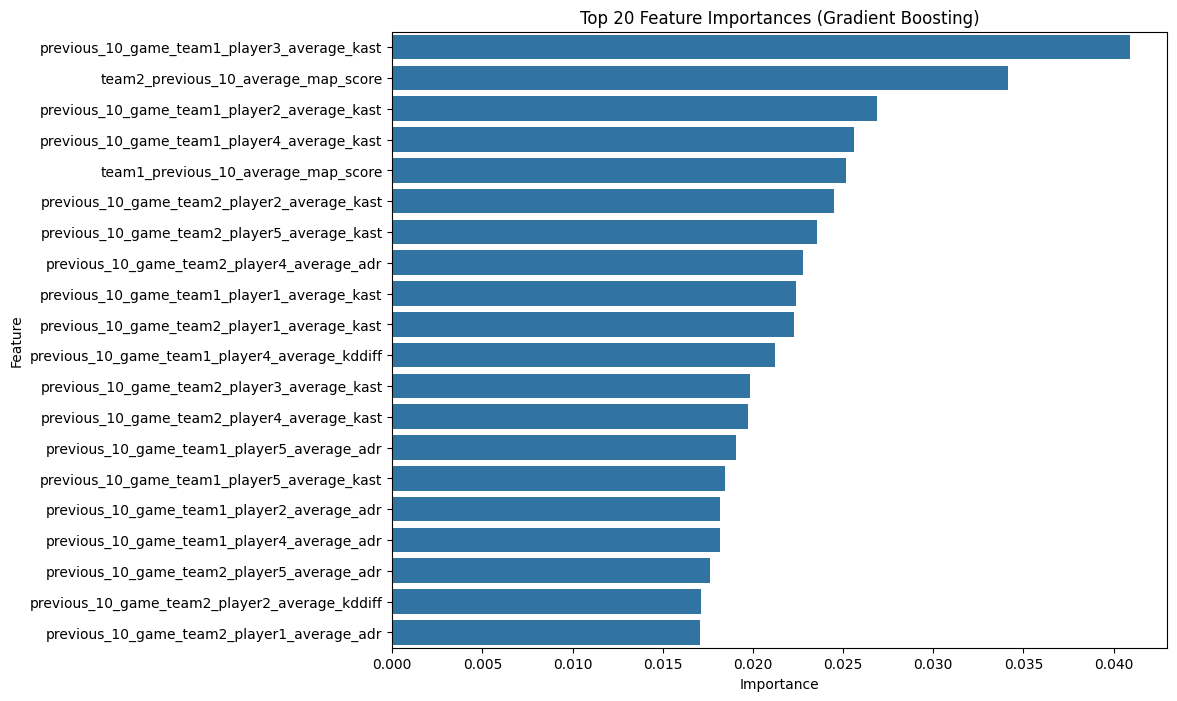

In [7]:
# Feature Importance
importances = gbm_best.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances (Gradient Boosting)')
plt.show()